In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.trainer import SobolevTrainer, GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import Put

from binomial_tree.binomial_tree import binomial_tree


In [13]:
S0 = 1.0
r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)
put_payoff = Put()

In [14]:
input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [25]:
loss_weights_sobolev = {
    'pde': 1.0,
    'J2': 0.30,
    'J3': 0.15,
    'J4': 0.80
}

Iteration 0, Loss: 0.23765383660793304
Iteration 100, Loss: 0.014888394623994827
Iteration 200, Loss: 0.005077245179563761
Iteration 300, Loss: 0.0021093892864882946
Iteration 400, Loss: 0.0018699208740144968
Iteration 500, Loss: 0.0006396342650987208
Iteration 600, Loss: 0.0012964827474206686
Iteration 700, Loss: 0.000889789080247283
Iteration 800, Loss: 0.0006797530804760754
Iteration 900, Loss: 0.0007203580462373793
Iteration 1000, Loss: 0.00038008607225492597
Iteration 1100, Loss: 0.0004365638305898756
Iteration 1200, Loss: 0.00035187345929443836
Iteration 1300, Loss: 0.0009066673228517175
Iteration 1400, Loss: 0.0006106323562562466
Iteration 1500, Loss: 0.0011271629482507706
Iteration 1600, Loss: 0.001356076099909842
Iteration 1700, Loss: 0.0004351395764388144
Iteration 1800, Loss: 0.0005920305848121643
Iteration 1900, Loss: 7.372105756076053e-05
Iteration 2000, Loss: 0.0005685745272785425
Iteration 2100, Loss: 0.00043339759577065706
Converged at epoch 2161


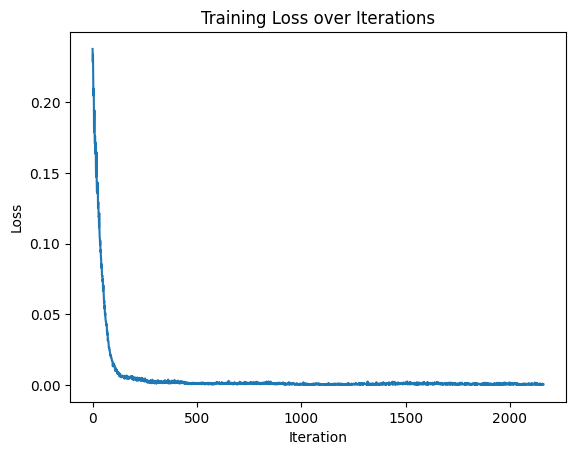

In [26]:
sobolev_trainer = SobolevTrainer(model_config, market_params, put_payoff, loss_weights=loss_weights_sobolev, seed=42)
sobolev_trainer.train(batch_size=1000, epochs=10000, tol=1e-6)
sobolev_trainer.plot_losses()

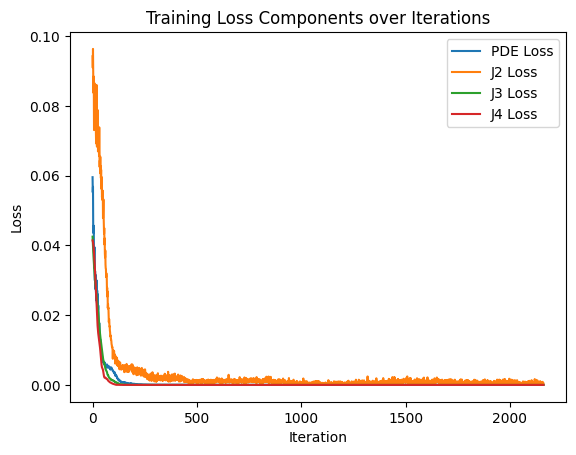

In [27]:
sobolev_trainer.plot_losses_detailed()

Iteration 0, Loss: 0.8332624435424805
Iteration 100, Loss: 0.021015677601099014
Converged at epoch 177


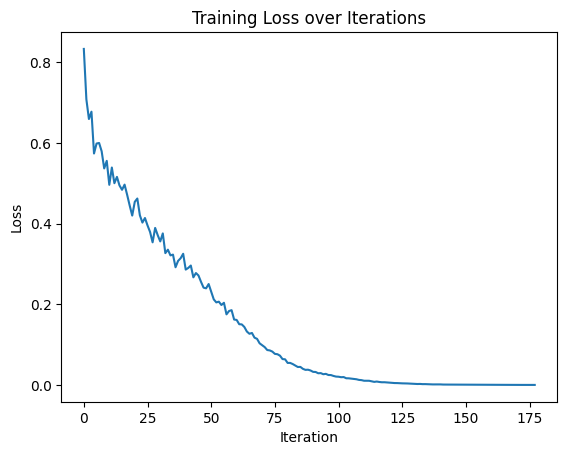

In [18]:
loss_weights = {
    'pde': 3.0,
    'exercise': 2.0,
    'boundary_Smax': 6,
    'boundary_Smin': 1/8
}

general_trainer = GeneralTrainer(model_config, market_params, put_payoff, loss_weights=loss_weights, seed=42)
general_trainer.train(batch_size=1000, epochs=10000, tol=1e-6)
general_trainer.plot_losses()

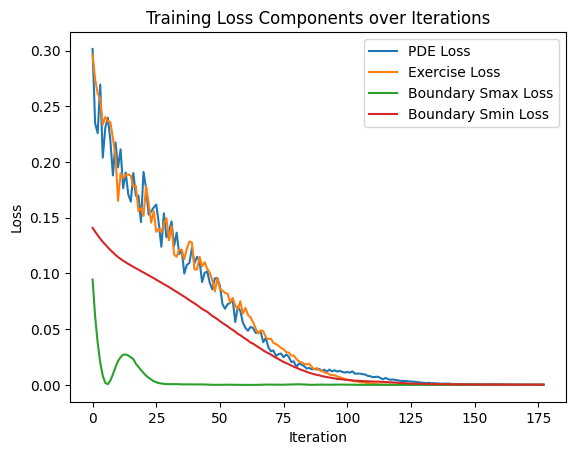

In [19]:
general_trainer.plot_losses_detailed()

In [28]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(1e-6, T, num_T)  # avoid exactly zero maturity

sb_prices = np.zeros((num_T, num_S))
nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        sb_prices[i, j] = sobolev_trainer.predict(t_val, s_val).item()
        nn_prices[i, j] = general_trainer.predict(t_val, s_val).item()
        bt_price, _, _ = binomial_tree(S=s_val, K=K, T=t_val, r=r, sigma=sigma, n=200)
        bt_prices[i, j] = float(bt_price)

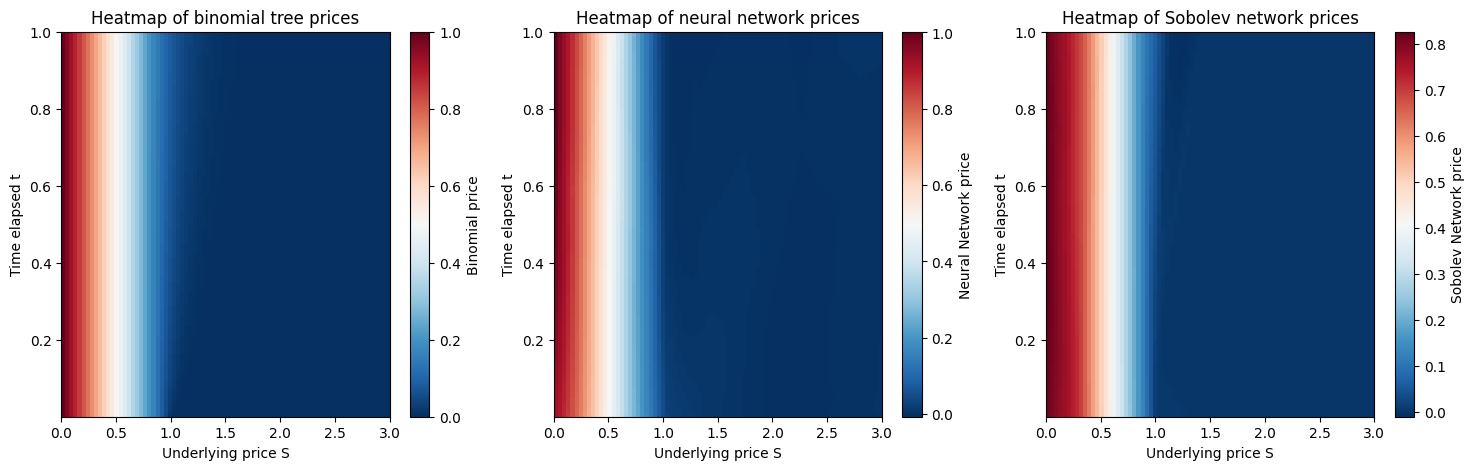

In [29]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
im = plt.imshow(bt_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of binomial tree prices')

plt.subplot(1, 3, 2)
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Neural Network price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of neural network prices')

plt.subplot(1, 3, 3)
im = plt.imshow(sb_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Sobolev Network price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of Sobolev network prices')

plt.show()

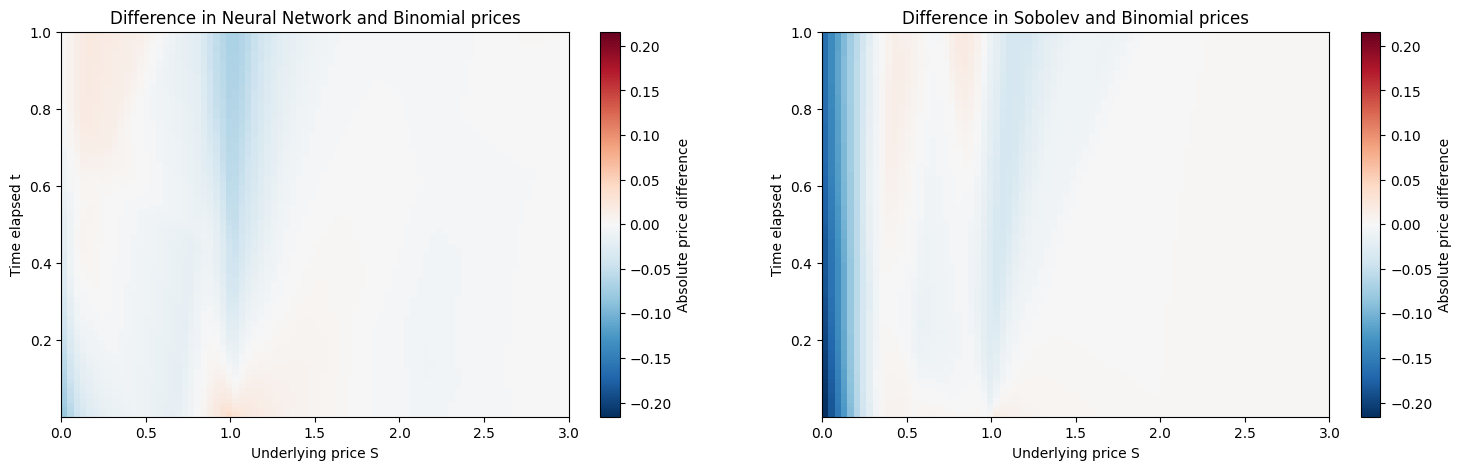

In [23]:
nn_bt_diff = nn_prices - bt_prices
sb_bt_diff = sb_prices - bt_prices

vmax = max(np.max(np.abs(nn_bt_diff)), np.max(np.abs(sb_bt_diff)))
vmin = -vmax

plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
im = plt.imshow(nn_bt_diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Difference in Neural Network and Binomial prices')

plt.subplot(1, 2, 2)
im = plt.imshow(sb_bt_diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Difference in Sobolev and Binomial prices')

plt.show()